# CytoVerse M4 Benchmark — analysis

MacBook Air M4, committed production build (onnxruntime-web 1.27, WebGPU + WASM fallback).
Query = seed-42 subsamples of the 599k-cell metaatlas (10k–500k); reference = **full SCimilarity**
(25M cells, 815 MB PQ index, 28,230-gene encoder). Runtime/memory scaling study.

Raw per-run JSON is in `../results/`. This notebook runs `../analyze.py`, which rebuilds the
summary table + `summary.csv` + the combined figure, then displays them inline.

**Headlines:** runtime is ~linear (13 s + 14.6 s/1k cells, R²=0.9997; only ~10% thermal spread);
memory is bounded (~2.7 GB base + ~4 KB/cell → 4.7 GB at 500k, well under 16 GB);
GPU/WebGPU ≈ CPU/WASM (GPU ~1.15× faster).

In [1]:
%matplotlib inline
# Rebuild table + fits + figure from ../results/*.json (writes summary.csv + m4_benchmark_figure.png)
%run ../analyze.py


  cells  dev  n   wall_s   s/1k  peak_MB atrest_MB
  10000  cpu  3    135.0  13.50     2776      2658
  25000  cpu  1    345.0  13.80     2915      2690
  50000  cpu  1    722.6  14.45     3010      2941
 100000  cpu  1   1511.8  15.12     3264      3210
 250000  cpu  1   3753.7  15.01     3846      3784
 500000  cpu  1   7271.7  14.54     4726      4564
  10000  gpu  3    114.0  11.40     2712      2606
  25000  gpu  1    303.1  12.12     2818      2701
  50000  gpu  1    641.1  12.82     2960      2802
 100000  gpu  1   1314.1  13.14     3239      3101

--- single linear fits ---
   cpu runtime:    13.0 s + 14.612 s/1k  (R2=0.99965)
   cpu memory :    2815 MB +  3.898 MB/1k = 3.99 KB/cell  (R2=0.99483)
   gpu runtime:   -25.7 s + 13.379 s/1k  (R2=0.99991)
   gpu memory :    2665 MB +  5.784 MB/1k = 5.92 KB/cell  (R2=0.99846)

  CPU s/1k range 13.50-15.12 -> throttle spread +12%
  CPU/GPU ratio 1.150 (GPU faster), shared sizes [10000, 25000, 50000, 100000]

wrote /Users/rcurrie/cytov

/Users/rcurrie/cytoverse.main/benchmark/m4/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:215: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


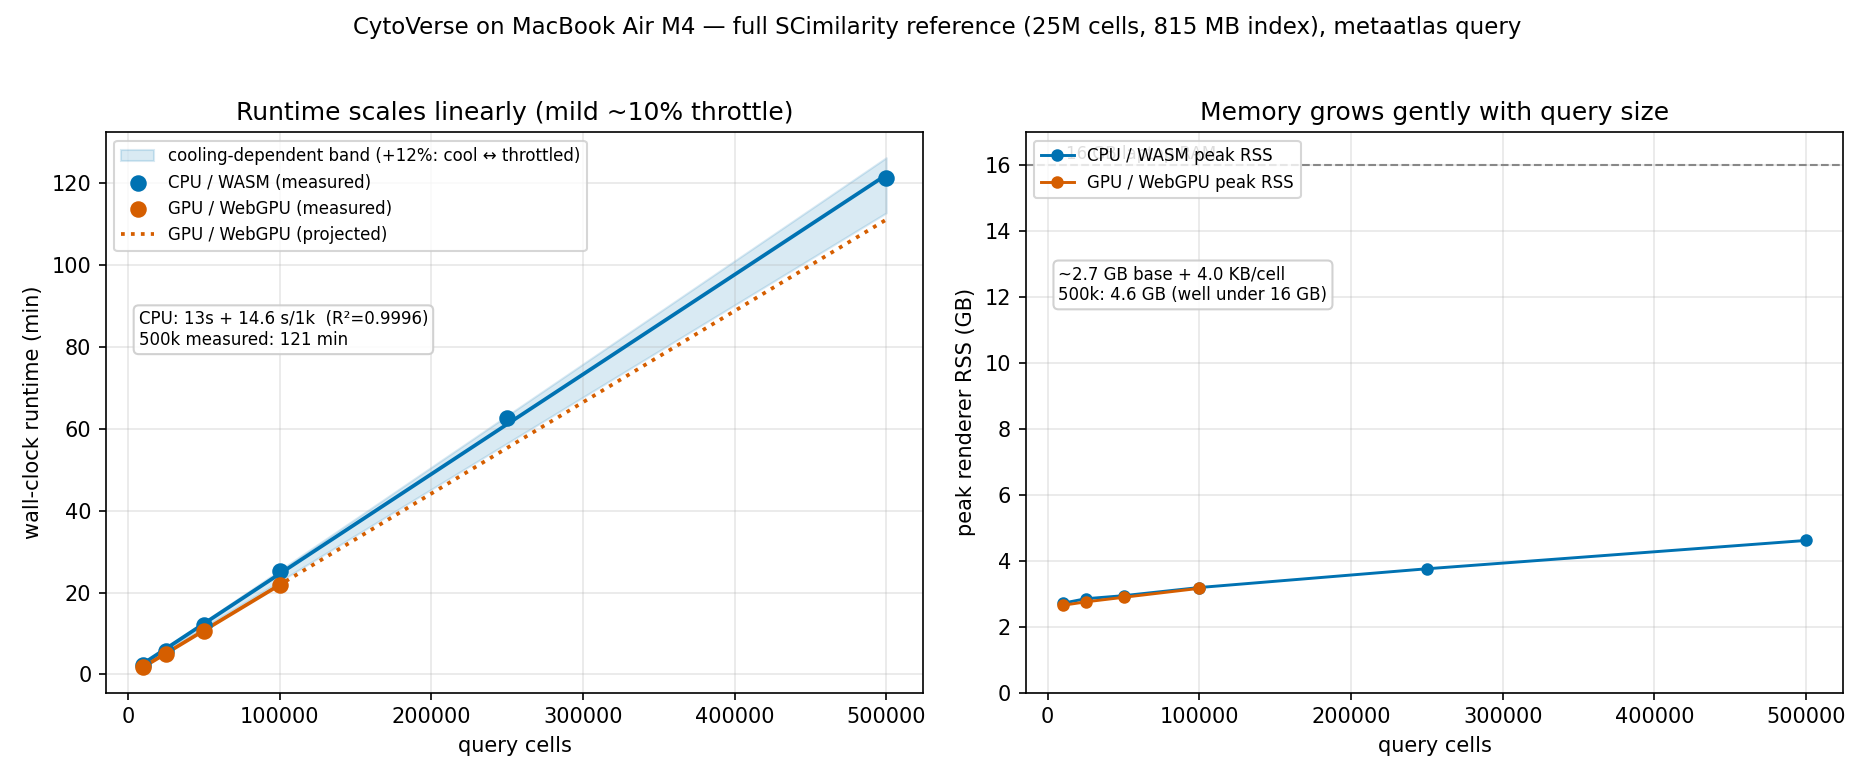

In [2]:
from IPython.display import Image
Image('../results/m4_benchmark_figure.png')

In [3]:
# Tidy table
import csv
with open('../results/summary.csv') as f:
    for row in csv.reader(f):
        print('  '.join(f'{c:>14}' for c in row))

         cells          device       n_repeats          wall_s        s_per_1k     peak_rss_mb  at_rest_rss_mb
         10000             cpu               3           135.0           13.50            2776            2658
         25000             cpu               1           345.0           13.80            2915            2690
         50000             cpu               1           722.6           14.45            3010            2941
        100000             cpu               1          1511.8           15.12            3264            3210
        250000             cpu               1          3753.7           15.01            3846            3784
        500000             cpu               1          7271.7           14.54            4726            4564
         10000             gpu               3           114.0           11.40            2712            2606
         25000             gpu               1           303.1           12.12            2818            2701
 

## Conclusion

On a fanless MacBook Air M4, CytoVerse labels query cells against the **full 25M-cell SCimilarity**
reference entirely in-browser with:

- **Runtime linear in query size** — `wall ≈ 13 s + 14.6 s/1k cells` (CPU/WASM), 500k cells in **2.0 h**
  measured directly. Sustained thermal throttling costs only ~10% (no 2× hot regime).
- **Memory bounded** — `~2.7 GB base + ~4 KB/cell`, peaking at **4.7 GB** at 500k, well under 16 GB.
- **GPU ≈ CPU** — WebGPU runs the encoder at rough parity (~1.15× faster than multithreaded WASM);
  it is transfer-bound, consistent with the discrete-NVIDIA result.

Full write-up + caveats in [`../RESULTS.md`](../RESULTS.md).